In [1]:
import sys
import os
import warnings

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src import mean_shift_density_enhancement, mean_shift_manifold_learning

In [3]:
manifold1 = np.stack([np.sin(np.arange(100)), np.cos(np.arange(100)), np.arange(100)], axis=1)

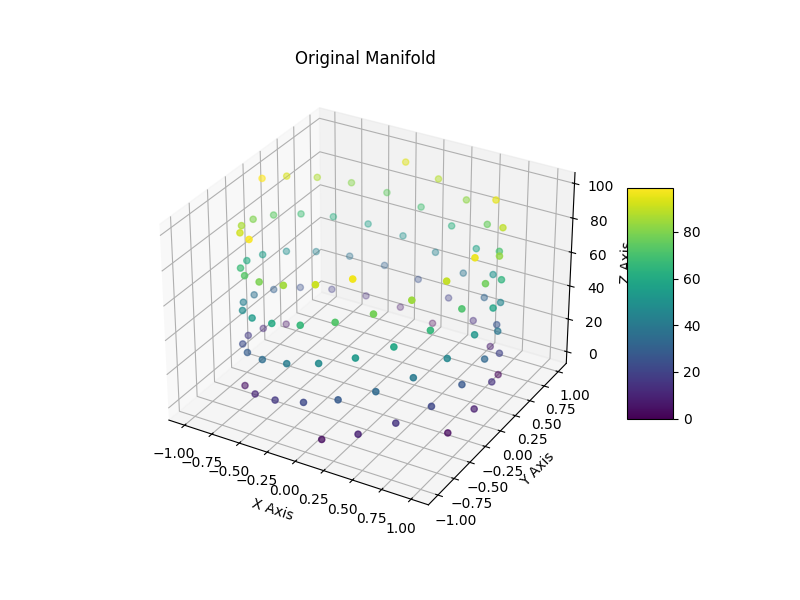

In [4]:
%matplotlib ipympl

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.scatter(manifold1[:, 0], manifold1[:, 1], manifold1[:, 2], c=manifold1[:, 2], cmap='viridis')

ax.set_title('Original Manifold')
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

In [5]:
manifold1 = manifold1 + np.random.rand(100, 3)

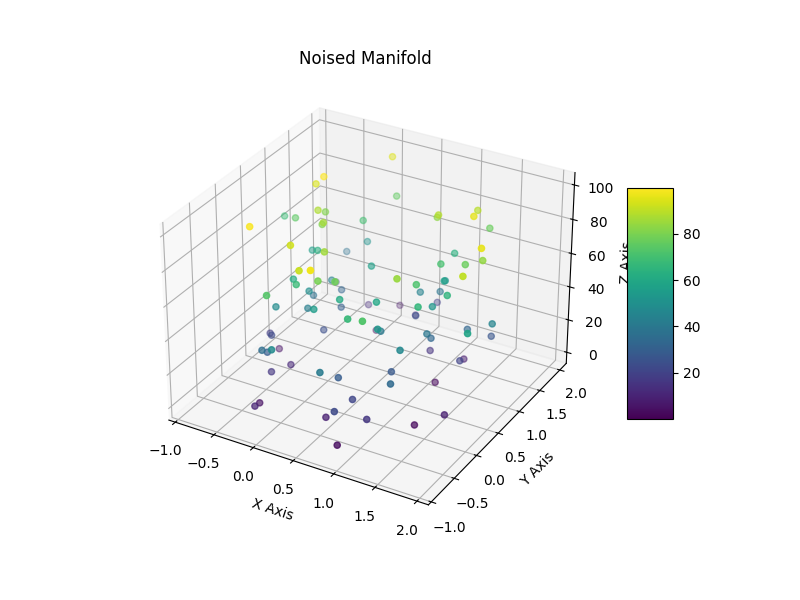

In [6]:
%matplotlib ipympl

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.scatter(manifold1[:, 0], manifold1[:, 1], manifold1[:, 2], c=manifold1[:, 2], cmap='viridis')

ax.set_title('Noised Manifold')
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

In [48]:
msde_data, _, _ = mean_shift_density_enhancement(manifold1, k=15, max_iters_shift=500, path="viz.npy")
dmsl_data, _, trajectory = mean_shift_manifold_learning(manifold1, k=10, max_iters_shift=50000)

Loading saved weights.


MSDE:  99%|█████████▉| 120/121 [00:03<00:00, 32.80it/s]


Total change converged after iteration 121. Exiting the loop.


DMSL shifts: 100%|██████████| 50000/50000 [00:06<00:00, 8071.37it/s]


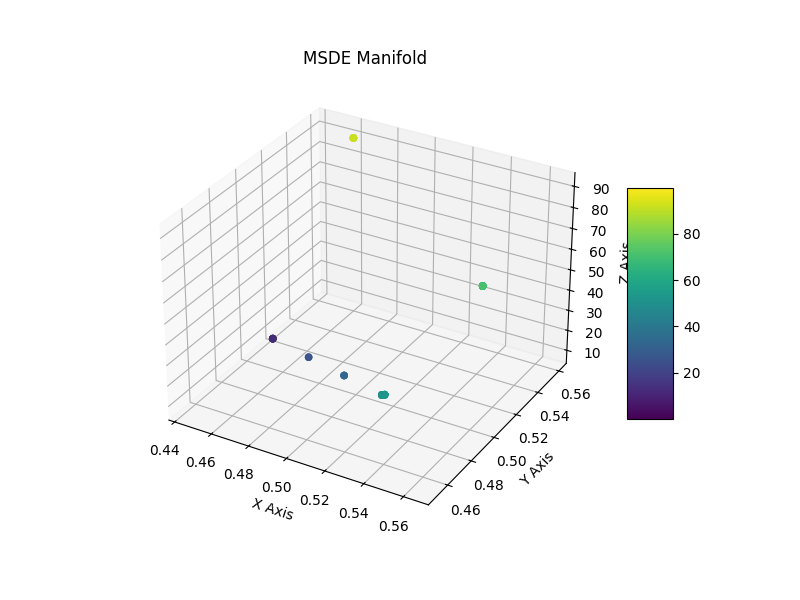

In [49]:
%matplotlib ipympl

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.scatter(msde_data[:, 0], msde_data[:, 1], msde_data[:, 2], c=manifold1[:, 2], cmap='viridis')

ax.set_title('MSDE Manifold')
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

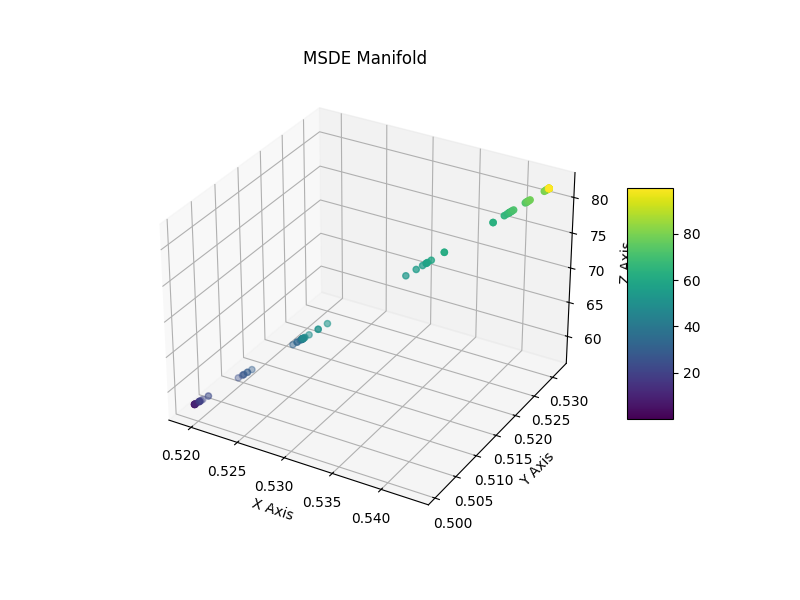

In [50]:
%matplotlib ipympl

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.scatter(dmsl_data[:, 0], dmsl_data[:, 1], dmsl_data[:, 2], c=manifold1[:, 2], cmap='viridis')

ax.set_title('MSDE Manifold')
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

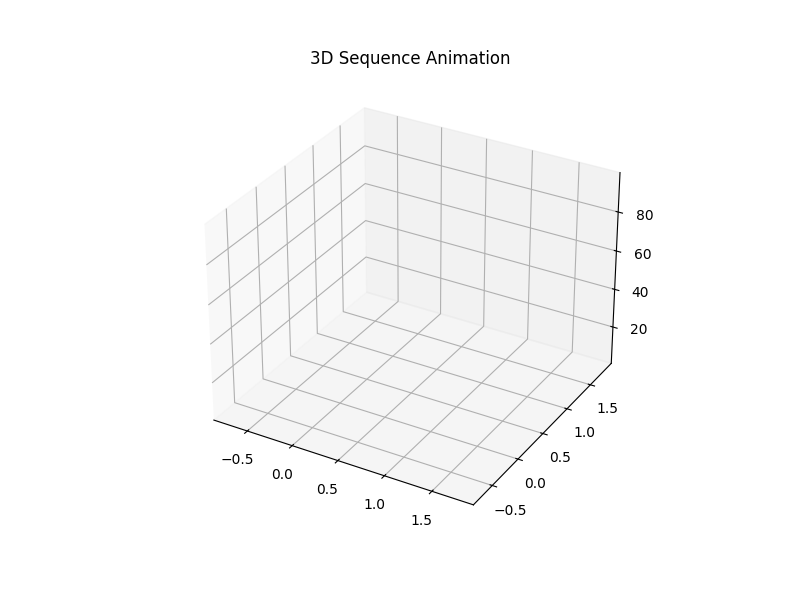

In [51]:
%matplotlib ipympl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --- 0. Setup Mock Data (Replace this with your actual list) ---
# Simulating a list of 50 frames, each containing a (100, 3) array
num_frames = 50

# --- 1. Compute Global Axis Limits (Prevents the 3D box from jumping) ---
all_data = np.vstack(trajectory)
x_min, x_max = all_data[:, 0].min(), all_data[:, 0].max()
y_min, y_max = all_data[:, 1].min(), all_data[:, 1].max()
z_min, z_max = all_data[:, 2].min(), all_data[:, 2].max()

# --- 2. Initialize Figure and 3D Plot ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Apply the stable limits
ax.set_xlim([x_min, x_max])
ax.set_ylim([y_min, y_max])
ax.set_zlim([z_min, z_max])
ax.set_title("3D Sequence Animation")

# Create an initial empty scatter plot
graph = ax.scatter([], [], [], c=[], cmap='viridis', vmin=z_min, vmax=z_max)

# --- 3. Define the Animation Update Loop ---
def update(frame_idx):
    # Grab the (100, 3) array for the current frame
    current_frame_data = trajectory[frame_idx]
    
    # Split into X, Y, Z vectors
    x = current_frame_data[:, 0]
    y = current_frame_data[:, 1]
    z = current_frame_data[:, 2]
    
    # Update positions and color arrays
    graph._offsets3d = (x, y, z)
    graph.set_array(z)
    
    # Optional: Rotate camera view dynamically over time
    ax.view_init(elev=20, azim=frame_idx * (360 / num_frames))
    
    return graph,

# --- 4. Run the Animation ---
# 'frames' matches the total number of arrays in your list
ani = animation.FuncAnimation(
    fig, 
    update, 
    frames=len(trajectory), 
    interval=100,  # 100ms delay between frames (10 FPS)
    blit=False
)

plt.show()
